# Project 3 — Credit Risk Modeling

**Course:** Introduction to Machine Learning  
**Dataset:** UCI Default of Credit Card Clients  
**Objective:** Predict the probability of borrower default next month

### Pipeline
1. Data loading
2. Exploratory Data Analysis (EDA)
3. Target visualization & class imbalance
4. Feature importance — Lasso + Random Forest
5. Train/Test split & imbalance strategies
6. Model training & cross-validation
7. Final evaluation (AUC, F1, Confusion Matrix, ROC)
8. Discussion & Conclusion

## 0. Imports

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from sklearn.base import clone
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    classification_report,
    confusion_matrix,
    f1_score,
    roc_auc_score,
    roc_curve,
    precision_score,
    recall_score,
)
from sklearn.model_selection import StratifiedKFold, cross_validate, train_test_split
from sklearn.neural_network import MLPClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.utils.class_weight import compute_class_weight

sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['axes.titlesize'] = 13

RANDOM_STATE = 42
OUTPUT_DIR = Path('outputs')
CM_DIR = OUTPUT_DIR / 'confusion_matrices'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
CM_DIR.mkdir(parents=True, exist_ok=True)

In [2]:
# Optional dependencies
try:
    from imblearn.over_sampling import SMOTE
    from imblearn.pipeline import Pipeline as ImbPipeline
except Exception as exc:
    raise RuntimeError('Installe imbalanced-learn: pip install imbalanced-learn') from exc

try:
    from xgboost import XGBClassifier
except Exception as exc:
    raise RuntimeError('XGBoost indisponible. Sur Mac: brew install libomp') from exc

## 1. Data Loading

In [3]:
def normalize_column_name(name: str) -> str:
    return (
        str(name).strip().lower()
        .replace(' ', '_').replace('.', '_')
        .replace('/', '_').replace('-', '_')
    )

def load_credit_dataset(data_path: Path) -> pd.DataFrame:
    if not data_path.exists():
        raise FileNotFoundError(f'Dataset introuvable: {data_path}')
    if data_path.suffix.lower() == '.csv':
        df = pd.read_csv(data_path)
    elif data_path.suffix.lower() in {'.xls', '.xlsx'}:
        try:
            df = pd.read_excel(data_path)
            if 'default.payment.next.month' not in [str(c) for c in df.columns]:
                df = pd.read_excel(data_path, header=1)
        except Exception:
            df = pd.read_excel(data_path, header=1)
    else:
        raise ValueError('Format non supporte: utilise .csv/.xls/.xlsx')
    df = df.loc[:, ~df.columns.astype(str).str.contains('^Unnamed')]
    df.columns = [normalize_column_name(c) for c in df.columns]
    return df

def detect_target_column(columns: list) -> str:
    for c in ['default_payment_next_month', 'default', 'y', 'target']:
        if c in columns:
            return c
    raise ValueError('Target introuvable: attendu default.payment.next.month')

# --- Chargement (Colab ou local) ---
try:
    from google.colab import files
    uploaded = files.upload()
    DATA_PATH = Path(next(iter(uploaded.keys())))
    print(f'Fichier charge via Colab: {DATA_PATH}')
except ImportError:
    DATA_PATH = Path('data/default_of_credit_card_clients.xls')
    print(f'Fallback local: {DATA_PATH}')

df = load_credit_dataset(DATA_PATH)
target_col = detect_target_column(list(df.columns))

# Supprimer colonne ID
id_cols = [c for c in df.columns if c in {'id', 'id_'} or c.startswith('id_')]
if id_cols:
    df = df.drop(columns=id_cols)

# Recoder valeurs aberrantes (EDUCATION, MARRIAGE)
if 'education' in df.columns:
    df['education'] = df['education'].replace({0: 4, 5: 4, 6: 4})
if 'marriage' in df.columns:
    df['marriage'] = df['marriage'].replace({0: 3})

print('Shape:', df.shape)
print('Target column:', target_col)
display(df.head())

Saving default_of_credit_card_clients.xls to default_of_credit_card_clients.xls
Fichier charge via Colab: default_of_credit_card_clients.xls
Shape: (30000, 24)
Target column: default_payment_next_month


,limit_bal,sex,education,marriage,age,pay_0,pay_2,pay_3,pay_4,pay_5,...,bill_amt4,bill_amt5,bill_amt6,pay_amt1,pay_amt2,pay_amt3,pay_amt4,pay_amt5,pay_amt6,default_payment_next_month
0,20000,2,2,1,24,2,2,-1,-1,-2,...,0,0,0,0,689,0,0,0,0,1
1,120000,2,2,2,26,-1,2,0,0,0,...,3272,3455,3261,0,1000,1000,1000,0,2000,1
2,90000,2,2,2,34,0,0,0,0,0,...,14331,14948,15549,1518,1500,1000,1000,1000,5000,0
3,50000,2,2,1,37,0,0,0,0,0,...,28314,28959,29547,2000,2019,1200,1100,1069,1000,0
4,50000,1,2,1,57,-1,0,-1,0,0,...,20940,19146,19131,2000,36681,10000,9000,689,679,0


## 2. Exploratory Data Analysis (EDA)

Avant de modéliser, on explore :
- la qualité des données (types, valeurs manquantes, doublons)
- les distributions des variables clés
- les corrélations
- les liens entre features et la cible

In [5]:
# --- 2.1 Qualite des donnees ---
print('=== Types de variables ===')
display(df.dtypes.value_counts().rename('count').to_frame())

print(f'\nDoublons: {df.duplicated().sum()}')

missing = df.isnull().sum().sort_values(ascending=False)
missing = missing[missing > 0]
print('\nValeurs manquantes:')
if len(missing) == 0:
    print('Aucune valeur manquante.')
else:
    display(missing.to_frame('missing_count'))

print('\nStatistiques descriptives:')
display(df.describe().T)

=== Types de variables ===


,count
int64,24



Doublons: 35

Valeurs manquantes:
Aucune valeur manquante.

Statistiques descriptives:


,count,mean,std,min,25%,50%,75%,max
limit_bal,30000.0,167484.322667,129747.661567,10000.0,50000.00,140000.0,240000.00,1000000.0
sex,30000.0,1.603733,0.489129,1.0,1.00,2.0,2.00,2.0
education,30000.0,1.842267,0.744494,1.0,1.00,2.0,2.00,4.0
marriage,30000.0,1.557267,0.521405,1.0,1.00,2.0,2.00,3.0
age,30000.0,35.485500,9.217904,21.0,28.00,34.0,41.00,79.0
pay_0,30000.0,-0.016700,1.123802,-2.0,-1.00,0.0,0.00,8.0
pay_2,30000.0,-0.133767,1.197186,-2.0,-1.00,0.0,0.00,8.0
pay_3,30000.0,-0.166200,1.196868,-2.0,-1.00,0.0,0.00,8.0
pay_4,30000.0,-0.220667,1.169139,-2.0,-1.00,0.0,0.00,8.0
pay_5,30000.0,-0.266200,1.133187,-2.0,-1.00,0.0,0.00,8.0


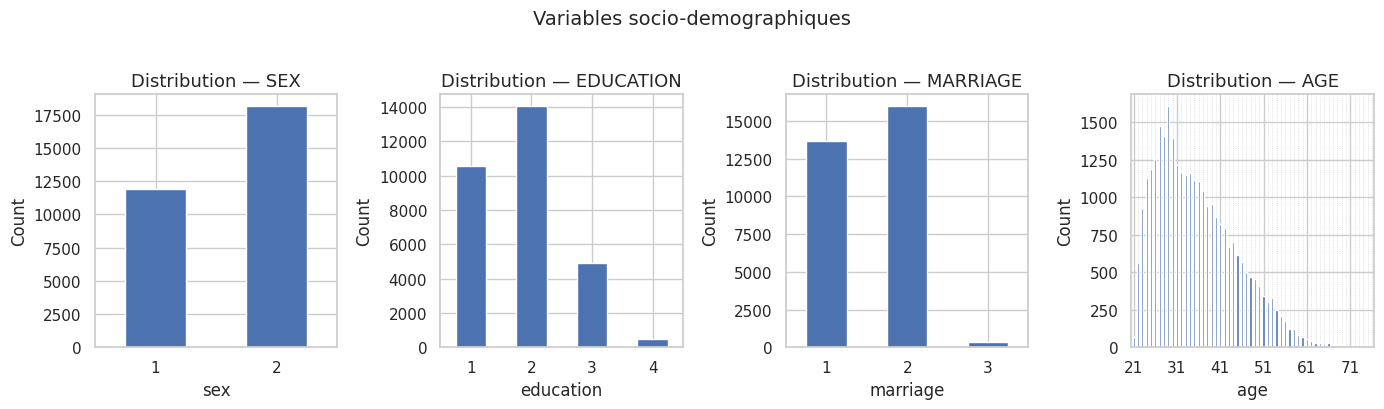

In [35]:
import matplotlib.ticker as mticker

# --- 2.2 Distributions des variables socio-demographiques ---
demo_cols = [c for c in ['sex', 'education', 'marriage', 'age'] if c in df.columns]

fig, axes = plt.subplots(1, len(demo_cols), figsize=(14, 4))
if len(demo_cols) == 1:
    axes = [axes]

for ax, col in zip(axes, demo_cols):
    df[col].value_counts().sort_index().plot(kind='bar', ax=ax, color='#4C72B0')
    ax.set_title(f'Distribution — {col.upper()}')
    ax.set_xlabel(col)
    ax.set_ylabel('Count')
    ax.tick_params(axis='x', rotation=0)

    # modify x axis numbers for age distribution
    if col.upper() == 'AGE':
      # Set major ticks every 10 units on axis
      major_locator = mticker.MultipleLocator(10)
      ax.xaxis.set_major_locator(major_locator)

      # Set minor ticks every 1 unit for grid steps
      minor_locator = mticker.MultipleLocator(1)
      ax.xaxis.set_minor_locator(minor_locator)
      ax.xaxis.grid(True, which='minor', linestyle=':', linewidth=0.5)

plt.suptitle('Variables socio-demographiques', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

/tmp/ipykernel_4160/2166252739.py:14: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(['Non-defaut (0)', 'Defaut (1)'])


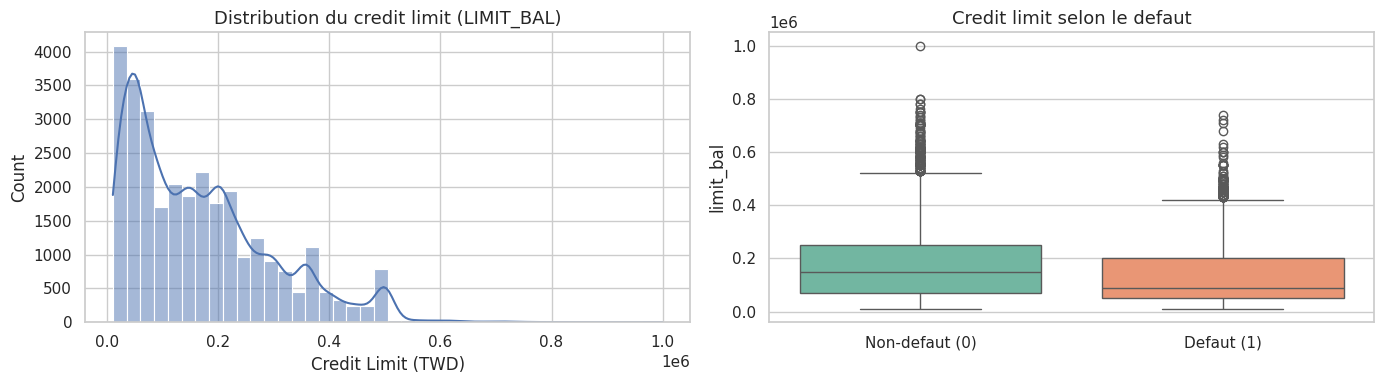

Observation: les clients en defaut ont en moyenne un credit limit plus faible.


In [7]:
# --- 2.3 Distribution du credit limit ---
if 'limit_bal' in df.columns:
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))

    sns.histplot(df['limit_bal'], bins=40, kde=True, ax=axes[0], color='#4C72B0')
    axes[0].set_title('Distribution du credit limit (LIMIT_BAL)')
    axes[0].set_xlabel('Credit Limit (TWD)')

    sns.boxplot(
        data=df, x=target_col, y='limit_bal', ax=axes[1],
        hue=target_col, palette='Set2', legend=False
    )
    axes[1].set_title('Credit limit selon le defaut')
    axes[1].set_xticklabels(['Non-defaut (0)', 'Defaut (1)'])
    axes[1].set_xlabel('')

    plt.tight_layout()
    plt.show()

    print('Observation: les clients en defaut ont en moyenne un credit limit plus faible.')

/tmp/ipykernel_4160/2813767746.py:19: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(['Non-defaut (0)', 'Defaut (1)'])


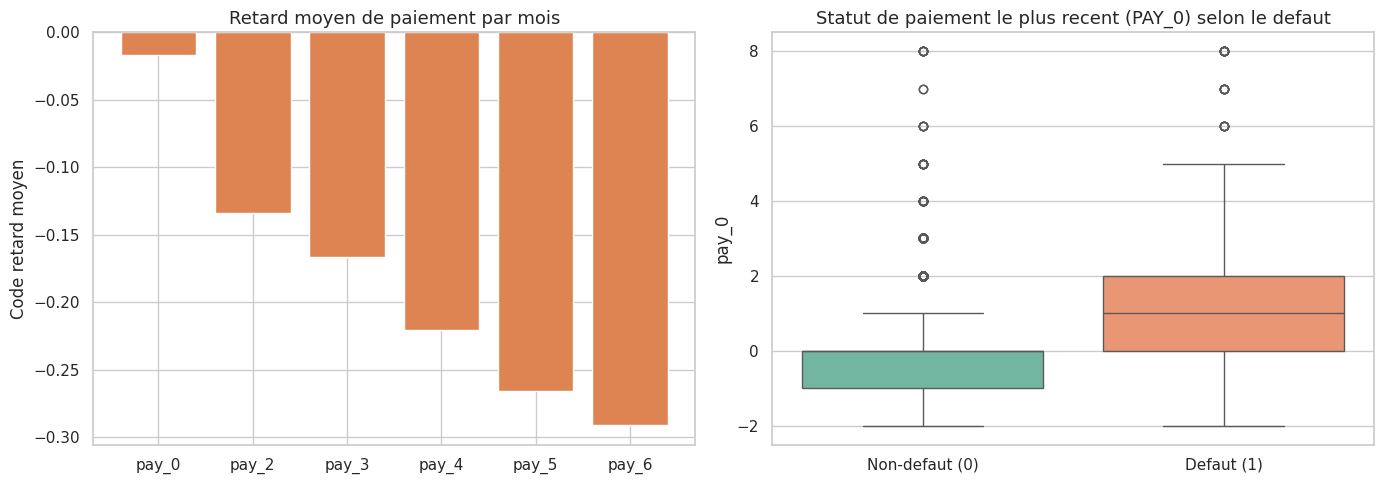


Taux de defaut selon le statut du paiement le plus recent:


,default_rate
pay_0,
-2,0.132
-1,0.168
0,0.128
1,0.339
2,0.691
3,0.758
4,0.684
5,0.500
6,0.545


Observation: un retard recent (PAY_0 > 0) multiplie par ~3 la probabilite de defaut.


In [39]:
# --- 2.4 Variables de retard de paiement (PAY_X) ---
pay_status_cols = [c for c in df.columns if c.startswith('pay_') and not c.startswith('pay_amt')]

if pay_status_cols:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    avg_delay = df[pay_status_cols].mean().sort_values(ascending=False)
    axes[0].bar(avg_delay.index, avg_delay.values, color='#DD8452')
    axes[0].set_title('Retard moyen de paiement par mois')
    axes[0].set_ylabel('Code retard moyen')
    axes[0].tick_params(axis='x', rotation=0)

    most_recent = pay_status_cols[0]  # pay_0 = plus recent
    sns.boxplot(
        data=df, x=target_col, y=most_recent, ax=axes[1],
        hue=target_col, palette='Set2', legend=False
    )
    axes[1].set_title(f'Statut de paiement le plus recent ({most_recent.upper()}) selon le defaut')
    axes[1].set_xticklabels(['Non-defaut (0)', 'Defaut (1)'])
    axes[1].set_xlabel('')

    plt.tight_layout()
    plt.show()

    # Taux de defaut selon PAY_0
    print('\nTaux de defaut selon le statut du paiement le plus recent:')
    display(
        df.groupby(most_recent)[target_col].mean()
        .rename('default_rate').round(3).to_frame()
    )
    print('Observation: un retard recent (PAY_0 > 0) multiplie par ~3 la probabilite de defaut.')

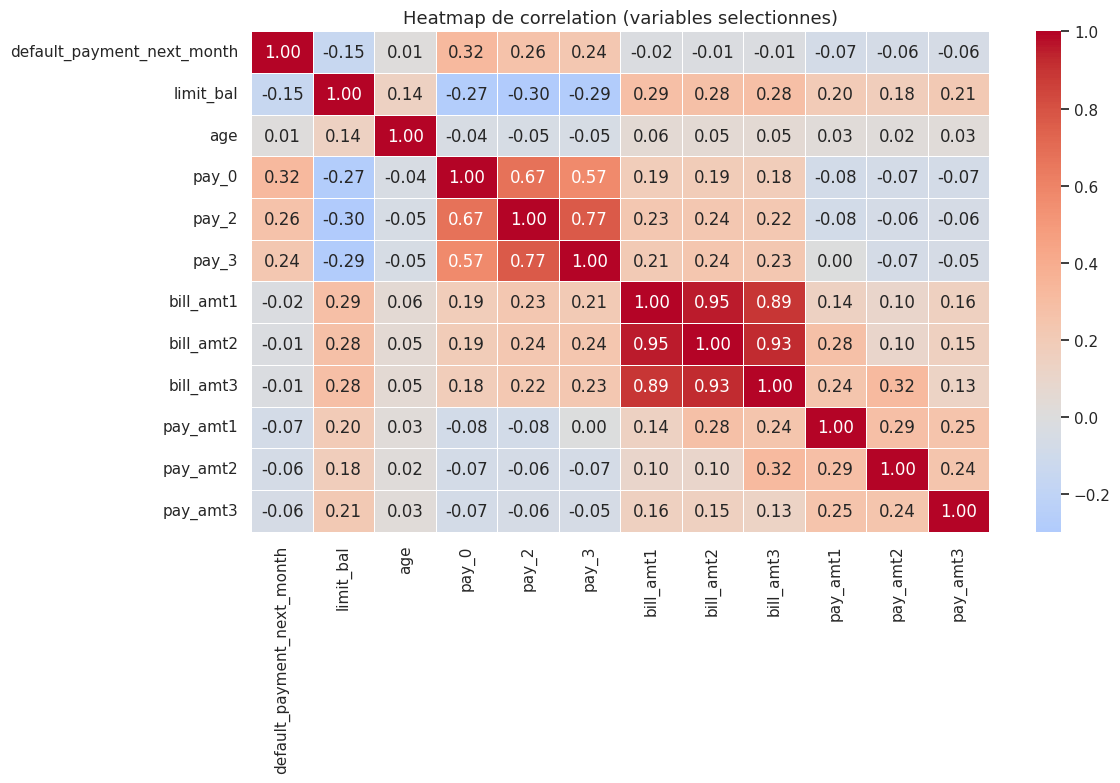

Observations cles:
- Les variables PAY_X sont positivement correlees avec le defaut
- LIMIT_BAL est negativement correlee avec le defaut (credit plus eleve = moins de risque)
- Les BILL_AMT sont fortement correles entre eux (multicollinearite)


In [9]:
# --- 2.5 Heatmap de correlation ---
key_cols = [target_col]
if 'limit_bal' in df.columns:
    key_cols.append('limit_bal')
if 'age' in df.columns:
    key_cols.append('age')
key_cols += [c for c in pay_status_cols[:3] if c in df.columns]
bill_cols = [c for c in df.columns if c.startswith('bill_amt')][:3]
pay_amt_cols = [c for c in df.columns if c.startswith('pay_amt')][:3]
key_cols += bill_cols + pay_amt_cols

corr = df[key_cols].corr()

plt.figure(figsize=(12, 8))
sns.heatmap(corr, cmap='coolwarm', center=0, annot=True, fmt='.2f', linewidths=0.5)
plt.title('Heatmap de correlation (variables selectionnes)')
plt.tight_layout()
plt.show()

print('Observations cles:')
print('- Les variables PAY_X sont positivement correlees avec le defaut')
print('- LIMIT_BAL est negativement correlee avec le defaut (credit plus eleve = moins de risque)')
print('- Les BILL_AMT sont fortement correles entre eux (multicollinearite)')

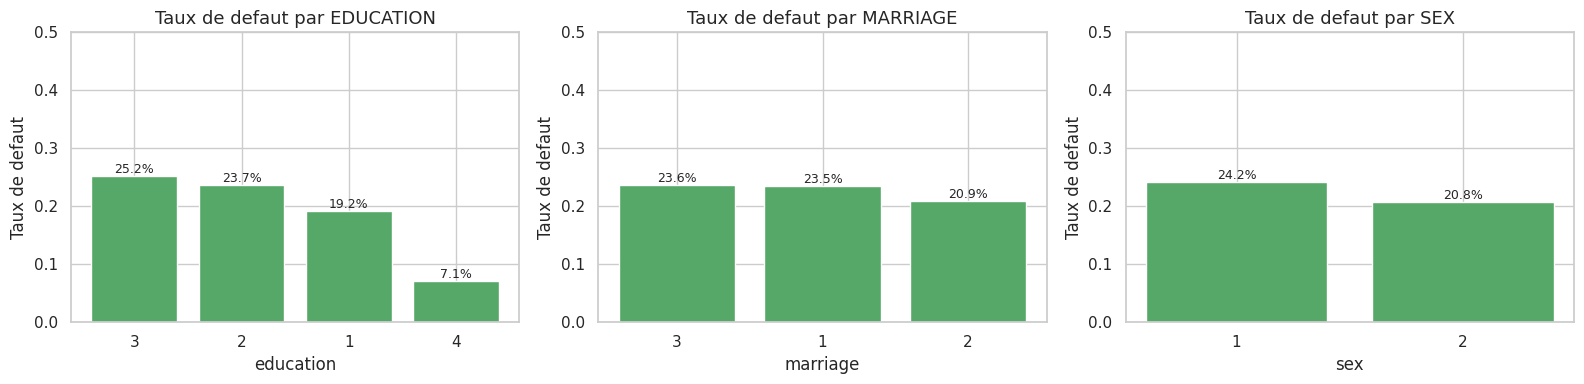

In [36]:
# --- 2.6 Taux de defaut par groupe ---
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

group_cols = [(c, ax) for c, ax in zip(
    [c for c in ['education', 'marriage', 'sex'] if c in df.columns],
    axes
)]

for col, ax in group_cols:
    rate = df.groupby(col)[target_col].mean().sort_values(ascending=False)
    ax.bar(rate.index.astype(str), rate.values, color='#55A868')
    ax.set_title(f'Taux de defaut par {col.upper()}')
    ax.set_ylabel('Taux de defaut')
    ax.set_xlabel(col)
    ax.set_ylim(0, 0.5)
    for i, v in enumerate(rate.values):
        ax.text(i, v + 0.005, f'{v:.1%}', ha='center', fontsize=9)

plt.tight_layout()
plt.show()

## 3. Visualisation de la cible & Desequilibre de classes

Le dataset est **desequilibre** : environ 22% de defauts seulement.  
Un modele naif qui predit toujours "non-defaut" aurait 78% de precision — ce qui est trompeur.  
Il faut donc utiliser des metriques adaptees (AUC, F1, Recall) et des strategies de rééquilibrage.

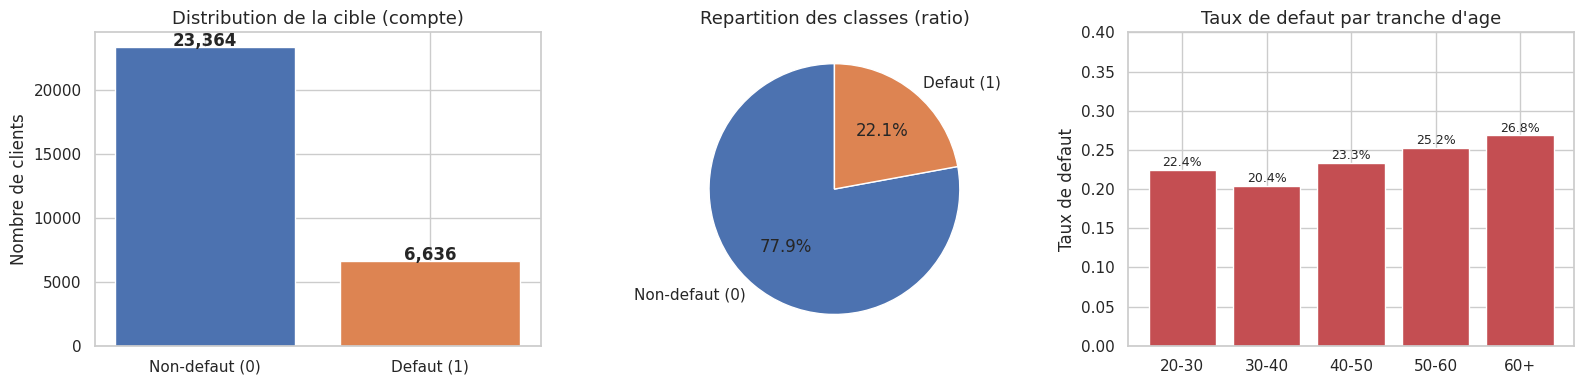

Distribution de la cible:


,count,ratio
default_payment_next_month,,
0,23364,0.7788
1,6636,0.2212



Ratio desequilibre: 3.5x plus de non-defauts que de defauts
=> Strategies pour gerer ce desequilibre: class_weight, scale_pos_weight, SMOTE


In [11]:
counts = df[target_col].value_counts().sort_index()
ratios = df[target_col].value_counts(normalize=True).sort_index()

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Barplot
axes[0].bar(['Non-defaut (0)', 'Defaut (1)'], counts.values,
            color=['#4C72B0', '#DD8452'])
axes[0].set_title('Distribution de la cible (compte)')
axes[0].set_ylabel('Nombre de clients')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 100, f'{v:,}', ha='center', fontweight='bold')

# Pie chart
axes[1].pie(
    counts.values,
    labels=['Non-defaut (0)', 'Defaut (1)'],
    autopct='%1.1f%%',
    colors=['#4C72B0', '#DD8452'],
    startangle=90
)
axes[1].set_title('Repartition des classes (ratio)')

# Taux de defaut par tranche d'age
if 'age' in df.columns:
    df['age_group'] = pd.cut(df['age'], bins=[20, 30, 40, 50, 60, 80],
                              labels=['20-30', '30-40', '40-50', '50-60', '60+'])
    default_by_age = df.groupby('age_group', observed=True)[target_col].mean()
    axes[2].bar(default_by_age.index.astype(str), default_by_age.values, color='#C44E52')
    axes[2].set_title('Taux de defaut par tranche d\'age')
    axes[2].set_ylabel('Taux de defaut')
    axes[2].set_ylim(0, 0.4)
    for i, v in enumerate(default_by_age.values):
        axes[2].text(i, v + 0.005, f'{v:.1%}', ha='center', fontsize=9)
    df = df.drop(columns=['age_group'])

plt.tight_layout()
plt.show()

print('Distribution de la cible:')
display(pd.DataFrame({'count': counts, 'ratio': ratios.round(4)}))
print(f"\nRatio desequilibre: {counts[0]/counts[1]:.1f}x plus de non-defauts que de defauts")
print('=> Strategies pour gerer ce desequilibre: class_weight, scale_pos_weight, SMOTE')

## 4. Feature Importance — Lasso & Random Forest

Avant de construire les modeles finaux, on identifie les variables les plus predictives avec :
- **Lasso (L1)** : penalise les coefficients peu utiles et les force a zero
- **Random Forest** : mesure l'importance via la reduction d'impurete de Gini

Cela permet de comprendre quelles variables "pèsent" le plus dans la prediction du defaut.

In [12]:
# Split preliminaire pour le screening des features
X_all = df.drop(columns=[target_col])
y_all = df[target_col].astype(int)

X_tr, X_te, y_tr, y_te = train_test_split(
    X_all, y_all, test_size=0.2, random_state=RANDOM_STATE, stratify=y_all
)

classes = np.array([0, 1])
weights = compute_class_weight(class_weight='balanced', classes=classes, y=y_tr)
class_weight_dict = {int(c): float(w) for c, w in zip(classes, weights)}
neg = int((y_tr == 0).sum())
pos = int((y_tr == 1).sum())
scale_pos_weight = neg / max(pos, 1)

print(f'Poids calcules pour gerer le desequilibre:')
print(f'  class_weight_dict = {class_weight_dict}')
print(f'  scale_pos_weight (XGBoost) = {scale_pos_weight:.2f}')
print(f'\nInterpretation: la classe minoritaire (defaut) est ponderee ~{class_weight_dict[1]:.1f}x plus fort')

Poids calcules pour gerer le desequilibre:
  class_weight_dict = {0: 0.6420202236370446, 1: 2.2603126765869277}
  scale_pos_weight (XGBoost) = 3.52

Interpretation: la classe minoritaire (defaut) est ponderee ~2.3x plus fort


Variables eliminees par Lasso (coefficient = 0): 2
Variables conservees: 21


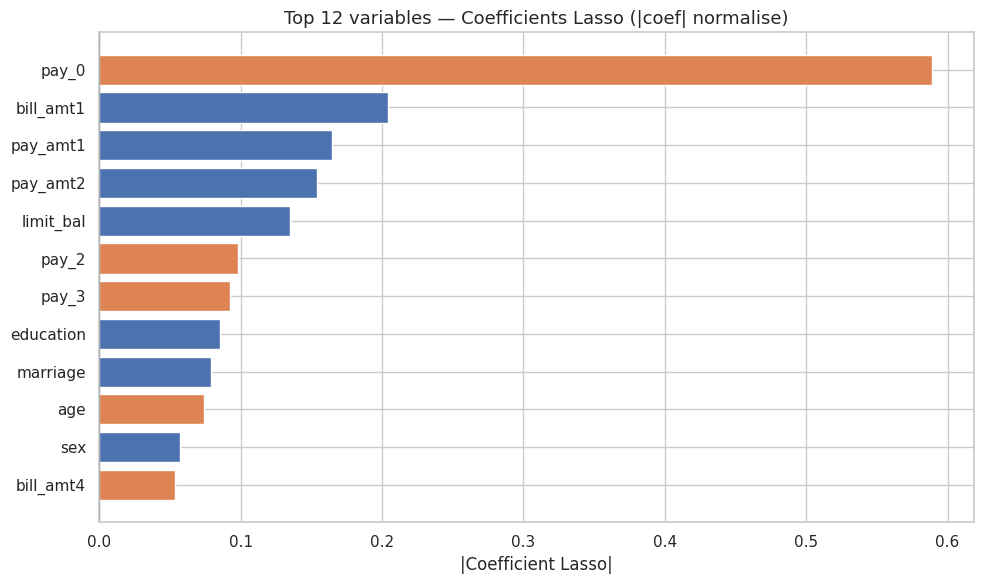


Top 10 features par Lasso:


,abs_lasso_coef
pay_0,0.5892
bill_amt1,0.2043
pay_amt1,0.1646
pay_amt2,0.1537
limit_bal,0.1350
pay_2,0.0983
pay_3,0.0922
education,0.0854
marriage,0.0787
age,0.0742


In [13]:
# --- 4.1 Lasso (Regression Logistique L1) ---
lasso_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(
        penalty='l1', solver='liblinear', C=0.1,
        class_weight=class_weight_dict,
        random_state=RANDOM_STATE, max_iter=2000
    ))
])
lasso_pipe.fit(X_tr, y_tr)

lasso_coef = pd.Series(
    lasso_pipe.named_steps['model'].coef_[0],
    index=X_tr.columns
)
lasso_top = lasso_coef.abs().sort_values(ascending=False).head(12)

print(f'Variables eliminees par Lasso (coefficient = 0): {(lasso_coef == 0).sum()}')
print(f'Variables conservees: {(lasso_coef != 0).sum()}')

# Plot Lasso
fig, ax = plt.subplots(figsize=(10, 6))
colors = ['#DD8452' if lasso_coef[f] > 0 else '#4C72B0' for f in lasso_top.index]
ax.barh(lasso_top.index[::-1], lasso_top.values[::-1], color=colors[::-1])
ax.set_title('Top 12 variables — Coefficients Lasso (|coef| normalise)')
ax.set_xlabel('|Coefficient Lasso|')
ax.axvline(x=0, color='black', linewidth=0.8)
plt.tight_layout()
plt.show()

print('\nTop 10 features par Lasso:')
display(lasso_coef.abs().sort_values(ascending=False).head(10).round(4).to_frame('abs_lasso_coef'))

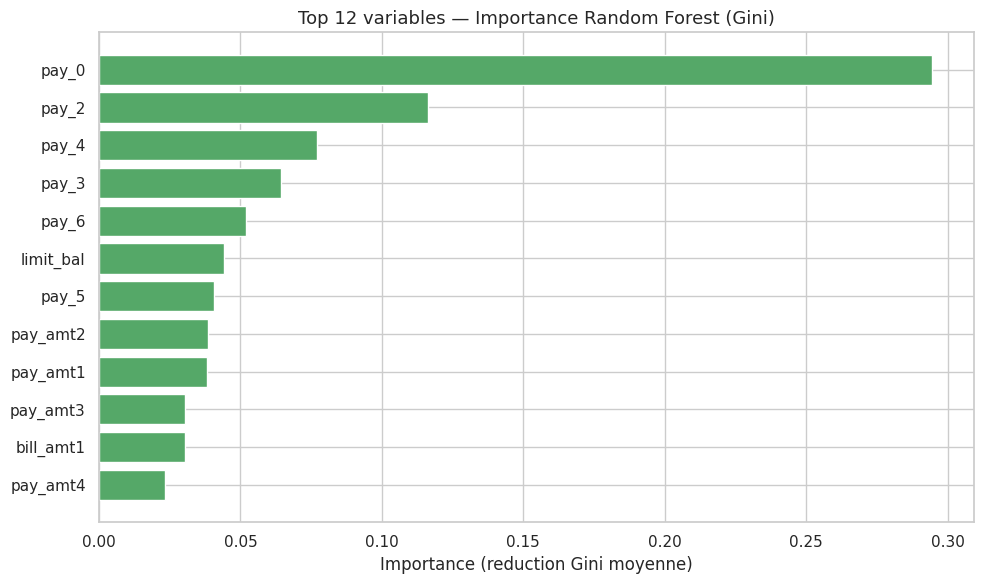


Top 10 features par Random Forest:


,rf_importance
pay_0,0.2946
pay_2,0.1163
pay_4,0.0770
pay_3,0.0643
pay_6,0.0519
limit_bal,0.0442
pay_5,0.0405
pay_amt2,0.0386
pay_amt1,0.0382
pay_amt3,0.0305


In [14]:
# --- 4.2 Random Forest — Importance des features ---
rf_selector = RandomForestClassifier(
    n_estimators=200, max_depth=8, min_samples_leaf=5,
    class_weight=class_weight_dict,
    random_state=RANDOM_STATE, n_jobs=-1
)
rf_selector.fit(X_tr, y_tr)

rf_importance = pd.Series(rf_selector.feature_importances_, index=X_tr.columns)
rf_top = rf_importance.sort_values(ascending=False).head(12)

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(rf_top.index[::-1], rf_top.values[::-1], color='#55A868')
ax.set_title('Top 12 variables — Importance Random Forest (Gini)')
ax.set_xlabel('Importance (reduction Gini moyenne)')
plt.tight_layout()
plt.show()

print('\nTop 10 features par Random Forest:')
display(rf_importance.sort_values(ascending=False).head(10).round(4).to_frame('rf_importance'))

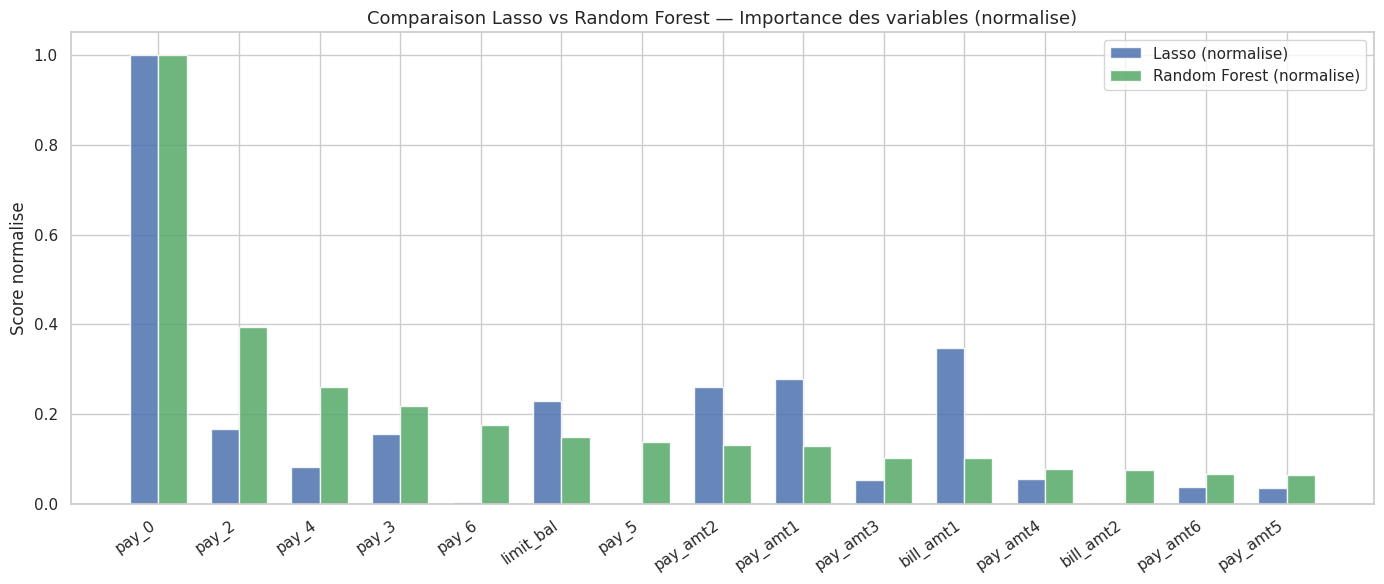

Colonnes de profil toujours conservees (5): ['limit_bal', 'sex', 'education', 'marriage', 'age']

Colonnes comportementales selectionnees par Lasso/RF (16):
['pay_0', 'pay_2', 'pay_3', 'pay_4', 'pay_6', 'bill_amt1', 'bill_amt2', 'bill_amt3', 'bill_amt4', 'bill_amt5', 'pay_amt1', 'pay_amt2', 'pay_amt3', 'pay_amt4', 'pay_amt5', 'pay_amt6']

Total features retenues: 21 / 23
Features supprimees: ['bill_amt6', 'pay_5']


/tmp/ipykernel_4160/3678902416.py:66: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(feature_screen['feature'], rotation=40, ha='right')


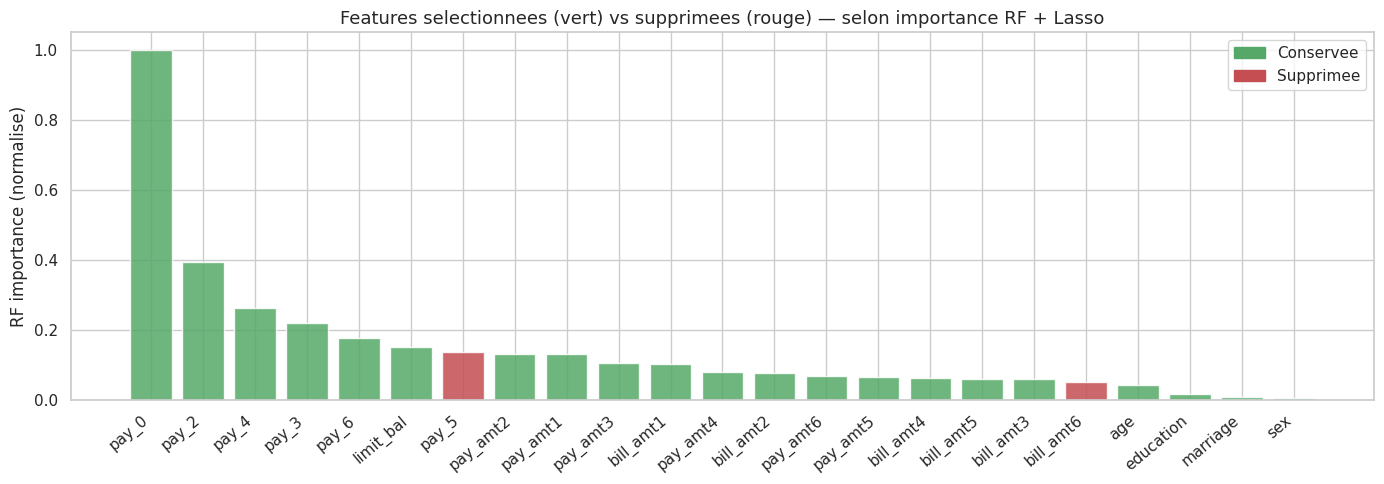

In [15]:
# --- 4.3 Comparaison Lasso vs Random Forest + Selection des features ---
feature_screen = pd.DataFrame({
    'feature': X_tr.columns,
    'lasso_abs_coef': lasso_coef.abs().values,
    'rf_importance': rf_importance.values
}).sort_values('rf_importance', ascending=False).reset_index(drop=True)

# Normalisation pour comparaison visuelle
feature_screen['lasso_norm'] = feature_screen['lasso_abs_coef'] / feature_screen['lasso_abs_coef'].max()
feature_screen['rf_norm'] = feature_screen['rf_importance'] / feature_screen['rf_importance'].max()

top15 = feature_screen.head(15)
x = np.arange(len(top15))
width = 0.35

fig, ax = plt.subplots(figsize=(14, 6))
ax.bar(x - width/2, top15['lasso_norm'], width, label='Lasso (normalise)', color='#4C72B0', alpha=0.85)
ax.bar(x + width/2, top15['rf_norm'], width, label='Random Forest (normalise)', color='#55A868', alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels(top15['feature'], rotation=35, ha='right')
ax.set_title('Comparaison Lasso vs Random Forest — Importance des variables (normalise)')
ax.set_ylabel('Score normalise')
ax.legend()
plt.tight_layout()
plt.show()

feature_screen.to_csv(OUTPUT_DIR / 'feature_screen_lasso_rf.csv', index=False)

# -------------------------------------------------------
# SELECTION AUTOMATIQUE DES FEATURES
# On garde :
#   - toujours : limit_bal, sex, education, marriage, age  (profil client)
#   - auto     : features PAY_X / BILL_AMT / PAY_AMT dont
#                RF importance > seuil OU Lasso coef != 0
# -------------------------------------------------------

# Colonnes de profil a toujours conserver
PROFILE_COLS = [c for c in ['limit_bal', 'sex', 'education', 'marriage', 'age'] if c in X_tr.columns]

# Colonnes "comportementales" candidates (pay_X, bill_amt, pay_amt)
behavioral_candidates = [c for c in X_tr.columns if c not in PROFILE_COLS]

# Seuil RF : on garde les features avec importance > moyenne
rf_threshold = rf_importance[behavioral_candidates].mean()
lasso_threshold = 0  # on garde si coef != 0

selected_behavioral = [
    c for c in behavioral_candidates
    if rf_importance[c] > rf_threshold or lasso_coef[c] != 0
]

SELECTED_FEATURES = PROFILE_COLS + selected_behavioral

print(f'Colonnes de profil toujours conservees ({len(PROFILE_COLS)}): {PROFILE_COLS}')
print()
print(f'Colonnes comportementales selectionnees par Lasso/RF ({len(selected_behavioral)}):')
print(selected_behavioral)
print()
print(f'Total features retenues: {len(SELECTED_FEATURES)} / {len(X_tr.columns)}')
print(f'Features supprimees: {list(set(X_tr.columns) - set(SELECTED_FEATURES))}')

# Visualisation : features retenues vs supprimees
fig, ax = plt.subplots(figsize=(14, 5))
colors_bar = ['#55A868' if c in SELECTED_FEATURES else '#C44E52' for c in feature_screen['feature']]
ax.bar(feature_screen['feature'], feature_screen['rf_norm'], color=colors_bar, alpha=0.85)
ax.set_xticklabels(feature_screen['feature'], rotation=40, ha='right')
ax.set_title('Features selectionnees (vert) vs supprimees (rouge) — selon importance RF + Lasso')
ax.set_ylabel('RF importance (normalise)')
from matplotlib.patches import Patch
ax.legend(handles=[
    Patch(color='#55A868', label='Conservee'),
    Patch(color='#C44E52', label='Supprimee')
])
plt.tight_layout()
plt.show()

## 5. Train/Test Split & Strategies de Gestion du Desequilibre

Apres la selection des features par Lasso + RF, on entraine les modeles uniquement sur les **features retenues**.

Les colonnes de **profil client** (`limit_bal`, `sex`, `education`, `marriage`, `age`) sont toujours conservees.  
Les colonnes **comportementales** (`pay_X`, `bill_amt`, `pay_amt`) sont filtrees selon deux criteres :
- RF importance > moyenne des importances comportementales
- OU coefficient Lasso != 0 (la variable apporte quelque chose)

Trois strategies complementaires pour gerer le desequilibre :
| Modele | Strategie |
|---|---|
| Logistic Regression | `class_weight='balanced'` (poids inverses aux frequences) |
| Random Forest | `class_weight='balanced'` |
| XGBoost | `scale_pos_weight` (ratio negatifs/positifs) |
| Neural Network (MLP) | **SMOTE** (sur-echantillonnage synthetique du train set uniquement) |

In [16]:
# Train/Test split avec les features selectionnees
X_train = X_tr[SELECTED_FEATURES]
X_test  = X_te[SELECTED_FEATURES]
y_train = y_tr
y_test  = y_te

print(f'Features retenues: {len(SELECTED_FEATURES)}')
print('Train shape:', X_train.shape)
print('Test  shape:', X_test.shape)
print()
print('Distribution train:')
display(y_train.value_counts().to_frame('count').assign(ratio=y_train.value_counts(normalize=True).round(4)))
print()
print('Distribution test (preservee grace au stratify):')
display(y_test.value_counts().to_frame('count').assign(ratio=y_test.value_counts(normalize=True).round(4)))

Features retenues: 21
Train shape: (24000, 21)
Test  shape: (6000, 21)

Distribution train:


,count,ratio
default_payment_next_month,,
0,18691,0.7788
1,5309,0.2212



Distribution test (preservee grace au stratify):


,count,ratio
default_payment_next_month,,
0,4673,0.7788
1,1327,0.2212


Avant SMOTE:
  Non-defaut: 18691 | Defaut: 5309

Apres SMOTE (pour MLP uniquement):
  Non-defaut: 18691 | Defaut: 18691


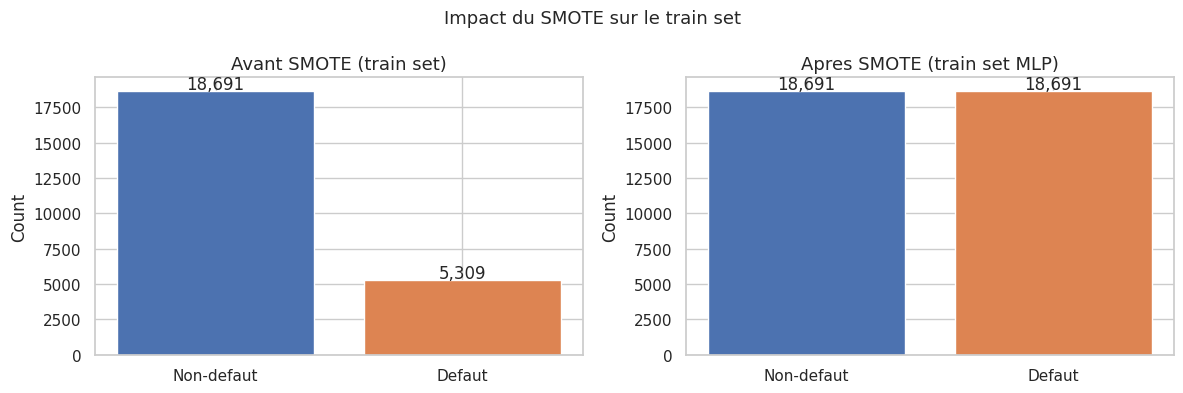


Important: SMOTE est applique uniquement sur le TRAIN set.
Le TEST set reste intact pour evaluer sur des donnees reelles.


In [17]:
# SMOTE sur le train set uniquement (jamais sur le test)
smote = SMOTE(random_state=RANDOM_STATE)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print('Avant SMOTE:')
print(f'  Non-defaut: {(y_train==0).sum()} | Defaut: {(y_train==1).sum()}')
print('\nApres SMOTE (pour MLP uniquement):')
print(f'  Non-defaut: {(y_train_smote==0).sum()} | Defaut: {(y_train_smote==1).sum()}')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
before = pd.Series(y_train).value_counts().sort_index()
after = pd.Series(y_train_smote).value_counts().sort_index()

axes[0].bar(['Non-defaut', 'Defaut'], before.values, color=['#4C72B0', '#DD8452'])
axes[0].set_title('Avant SMOTE (train set)')
axes[0].set_ylabel('Count')
for i, v in enumerate(before.values):
    axes[0].text(i, v+100, f'{v:,}', ha='center')

axes[1].bar(['Non-defaut', 'Defaut'], after.values, color=['#4C72B0', '#DD8452'])
axes[1].set_title('Apres SMOTE (train set MLP)')
axes[1].set_ylabel('Count')
for i, v in enumerate(after.values):
    axes[1].text(i, v+100, f'{v:,}', ha='center')

plt.suptitle('Impact du SMOTE sur le train set', fontsize=13)
plt.tight_layout()
plt.show()

print('\nImportant: SMOTE est applique uniquement sur le TRAIN set.')
print('Le TEST set reste intact pour evaluer sur des donnees reelles.')

## 6. Definition des Modeles

In [18]:
models = {
    'Logistic Regression': Pipeline([
        ('scaler', StandardScaler()),
        ('model', LogisticRegression(
            max_iter=2000,
            class_weight=class_weight_dict,  # gestion desequilibre
            random_state=RANDOM_STATE
        ))
    ]),

    'Random Forest': RandomForestClassifier(
        n_estimators=300,
        max_depth=10,
        min_samples_leaf=5,
        class_weight=class_weight_dict,   # gestion desequilibre
        random_state=RANDOM_STATE,
        n_jobs=-1
    ),

    'XGBoost': XGBClassifier(
        n_estimators=300,
        max_depth=4,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        objective='binary:logistic',
        eval_metric='auc',
        random_state=RANDOM_STATE,
        n_jobs=-1,
        scale_pos_weight=scale_pos_weight  # gestion desequilibre
    ),

    'Neural Network (MLP)': Pipeline([
        ('scaler', StandardScaler()),
        ('model', MLPClassifier(
            hidden_layer_sizes=(64, 32),
            max_iter=300,
            early_stopping=True,
            random_state=RANDOM_STATE
        ))
    ])  # gestion desequilibre via SMOTE sur le train
}

print('Strategies de gestion du desequilibre:')
print('  Logistic Regression -> class_weight (poids inverses)')
print('  Random Forest       -> class_weight (poids inverses)')
print('  XGBoost             -> scale_pos_weight =', round(scale_pos_weight, 2))
print('  Neural Network MLP  -> SMOTE sur le train set')

Strategies de gestion du desequilibre:
  Logistic Regression -> class_weight (poids inverses)
  Random Forest       -> class_weight (poids inverses)
  XGBoost             -> scale_pos_weight = 3.52
  Neural Network MLP  -> SMOTE sur le train set


## 7. Cross-Validation (3-fold stratifie)

In [19]:
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)

# MLP dans un ImbPipeline pour integrer SMOTE dans chaque fold
cv_models = {
    'Logistic Regression': clone(models['Logistic Regression']),
    'Random Forest': clone(models['Random Forest']),
    'XGBoost': clone(models['XGBoost']),
    'Neural Network (MLP)': ImbPipeline([
        ('smote', SMOTE(random_state=RANDOM_STATE)),
        ('scaler', StandardScaler()),
        ('model', MLPClassifier(
            hidden_layer_sizes=(64, 32),
            max_iter=300,
            early_stopping=True,
            random_state=RANDOM_STATE
        ))
    ])
}

cv_rows = []
for model_name, model in cv_models.items():
    print(f'Cross-validation: {model_name}...')
    scores = cross_validate(
        model, X_train, y_train,
        cv=cv,
        scoring={'auc': 'roc_auc', 'f1': 'f1', 'recall': 'recall'},
        n_jobs=-1, error_score='raise'
    )
    cv_rows.append({
        'Model': model_name,
        'CV AUC': round(float(np.mean(scores['test_auc'])), 4),
        'CV AUC std': round(float(np.std(scores['test_auc'])), 4),
        'CV F1': round(float(np.mean(scores['test_f1'])), 4),
        'CV Recall': round(float(np.mean(scores['test_recall'])), 4),
    })

cv_df = pd.DataFrame(cv_rows).sort_values('CV AUC', ascending=False).reset_index(drop=True)
print('\nResultats Cross-Validation:')
display(cv_df)
cv_df.to_csv(OUTPUT_DIR / 'cv_results.csv', index=False)

Cross-validation: Logistic Regression...
Cross-validation: Random Forest...
Cross-validation: XGBoost...
Cross-validation: Neural Network (MLP)...

Resultats Cross-Validation:


,Model,CV AUC,CV AUC std,CV F1,CV Recall
0,XGBoost,0.7821,0.0069,0.5403,0.6306
1,Random Forest,0.7812,0.0040,0.5417,0.5638
2,Neural Network (MLP),0.7377,0.0085,0.4894,0.5604
3,Logistic Regression,0.7263,0.0115,0.4794,0.6444


## 8. Evaluation Finale sur le Test Set

Entrainement: Logistic Regression...


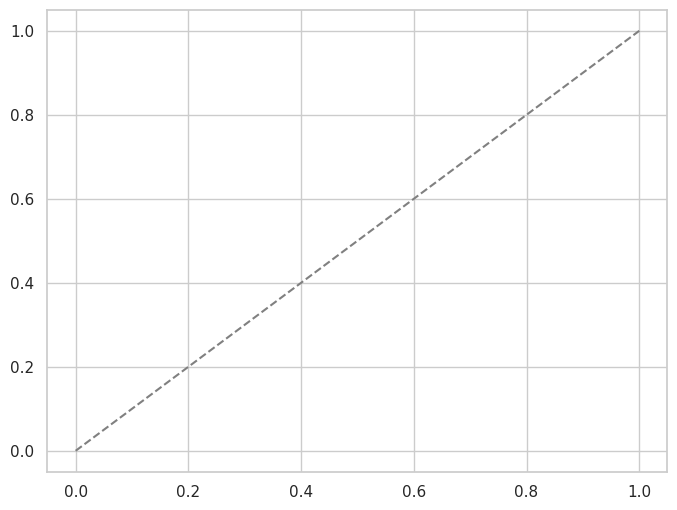

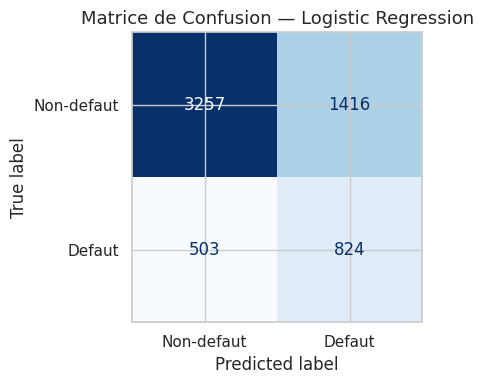

Entrainement: Random Forest...


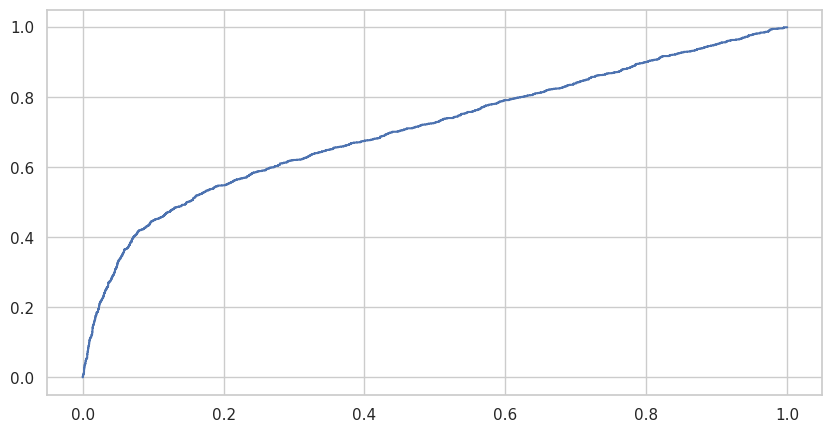

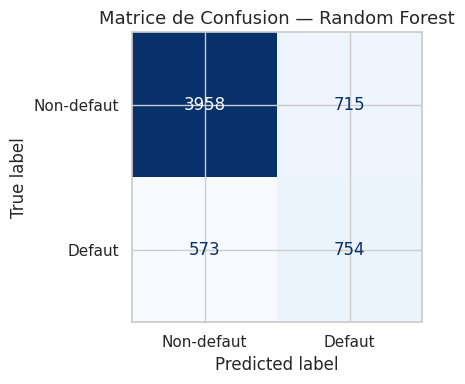

Entrainement: XGBoost...


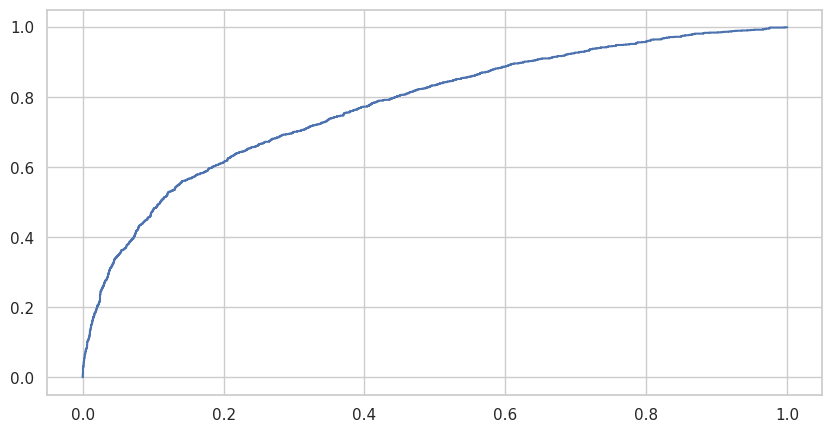

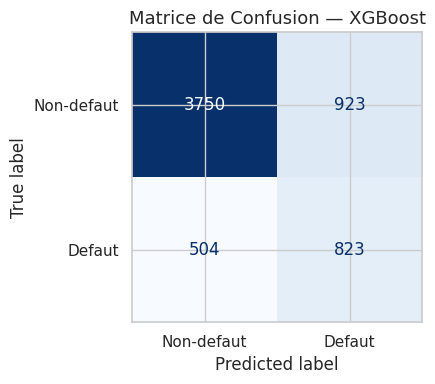

Entrainement: Neural Network (MLP)...


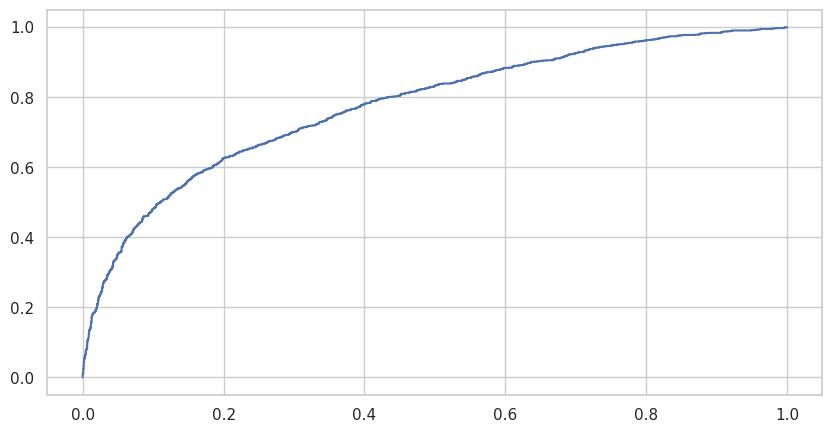

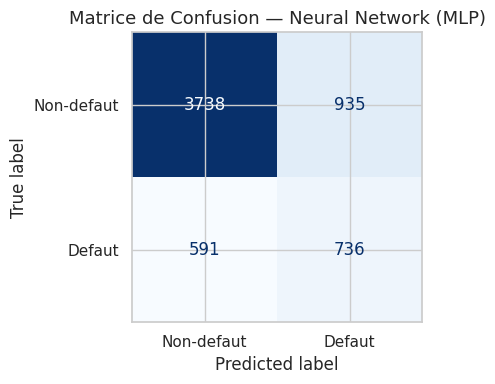

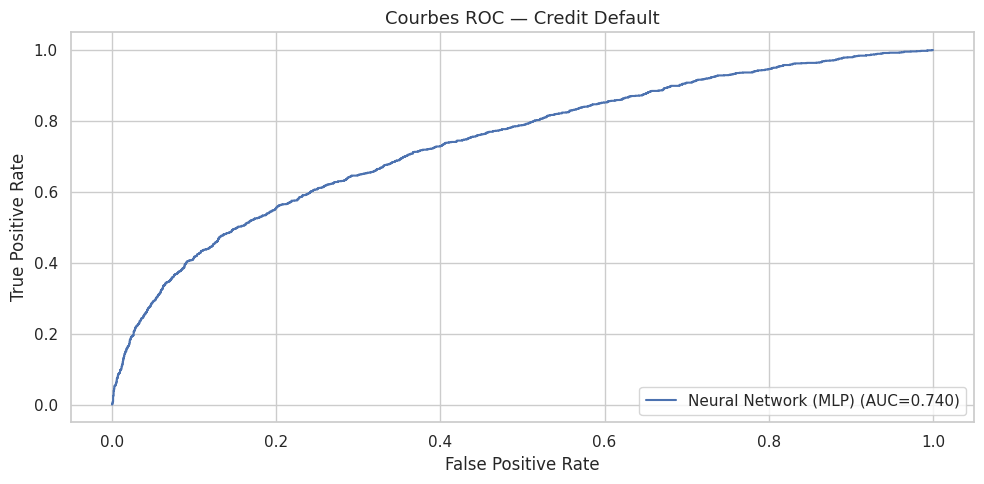

,Model,AUC,F1,Recall (defaut),Precision (defaut),TN,FP,FN,TP
0,XGBoost,0.7765,0.5356,0.6202,0.4714,3750,923,504,823
1,Random Forest,0.7760,0.5393,0.5682,0.5133,3958,715,573,754
2,Neural Network (MLP),0.7401,0.4910,0.5546,0.4405,3738,935,591,736
3,Logistic Regression,0.7085,0.4620,0.6209,0.3679,3257,1416,503,824


Resultats sauvegardes: /content/outputs


In [20]:
results = []

plt.figure(figsize=(8, 6))
plt.plot([0, 1], [0, 1], linestyle='--', color='grey', label='Classifieur aleatoire')

for model_name, model in models.items():
    print(f'Entrainement: {model_name}...')
    if model_name == 'Neural Network (MLP)':
        model.fit(X_train_smote, y_train_smote)
    else:
        model.fit(X_train, y_train)

    y_prob = model.predict_proba(X_test)[:, 1]
    y_pred = (y_prob >= 0.5).astype(int)

    auc = roc_auc_score(y_test, y_prob)
    f1 = f1_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, zero_division=0)
    cm = confusion_matrix(y_test, y_pred)

    results.append({
        'Model': model_name,
        'AUC': round(float(auc), 4),
        'F1': round(float(f1), 4),
        'Recall (defaut)': round(float(recall), 4),
        'Precision (defaut)': round(float(precision), 4),
        'TN': int(cm[0, 0]), 'FP': int(cm[0, 1]),
        'FN': int(cm[1, 0]), 'TP': int(cm[1, 1]),
    })

    # Confusion matrix
    fig_cm, ax_cm = plt.subplots(figsize=(5, 4))
    ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Non-defaut', 'Defaut']).plot(
        ax=ax_cm, colorbar=False, cmap='Blues'
    )
    ax_cm.set_title(f'Matrice de Confusion — {model_name}')
    plt.tight_layout()
    safe_name = model_name.lower().replace(' ', '_').replace('(', '').replace(')', '')
    fig_cm.savefig(CM_DIR / f'cm_{safe_name}.png', dpi=100)
    plt.show()
    plt.close(fig_cm)

    # ROC curve
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    plt.figure(1)
    plt.plot(fpr, tpr, label=f'{model_name} (AUC={auc:.3f})')

plt.figure(1)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Courbes ROC — Credit Default')
plt.legend(loc='lower right')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'roc_curves.png', dpi=100)
plt.show()

results_df = pd.DataFrame(results).sort_values('AUC', ascending=False).reset_index(drop=True)
display(results_df)
results_df.to_csv(OUTPUT_DIR / 'model_results.csv', index=False)
print(f'Resultats sauvegardes: {OUTPUT_DIR.resolve()}')

In [21]:
# --- Tableau de synthese final ---
if 'cv_df' in dir():
    final_df = results_df[['Model', 'AUC', 'F1', 'Recall (defaut)', 'Precision (defaut)']].merge(
        cv_df[['Model', 'CV AUC', 'CV AUC std', 'CV F1', 'CV Recall']],
        on='Model', how='left'
    )
    print('=== Tableau de synthese complet ===')
    display(final_df)
    final_df.to_csv(OUTPUT_DIR / 'final_summary.csv', index=False)

=== Tableau de synthese complet ===


,Model,AUC,F1,Recall (defaut),Precision (defaut),CV AUC,CV AUC std,CV F1,CV Recall
0,XGBoost,0.7765,0.5356,0.6202,0.4714,0.7821,0.0069,0.5403,0.6306
1,Random Forest,0.7760,0.5393,0.5682,0.5133,0.7812,0.0040,0.5417,0.5638
2,Neural Network (MLP),0.7401,0.4910,0.5546,0.4405,0.7377,0.0085,0.4894,0.5604
3,Logistic Regression,0.7085,0.4620,0.6209,0.3679,0.7263,0.0115,0.4794,0.6444


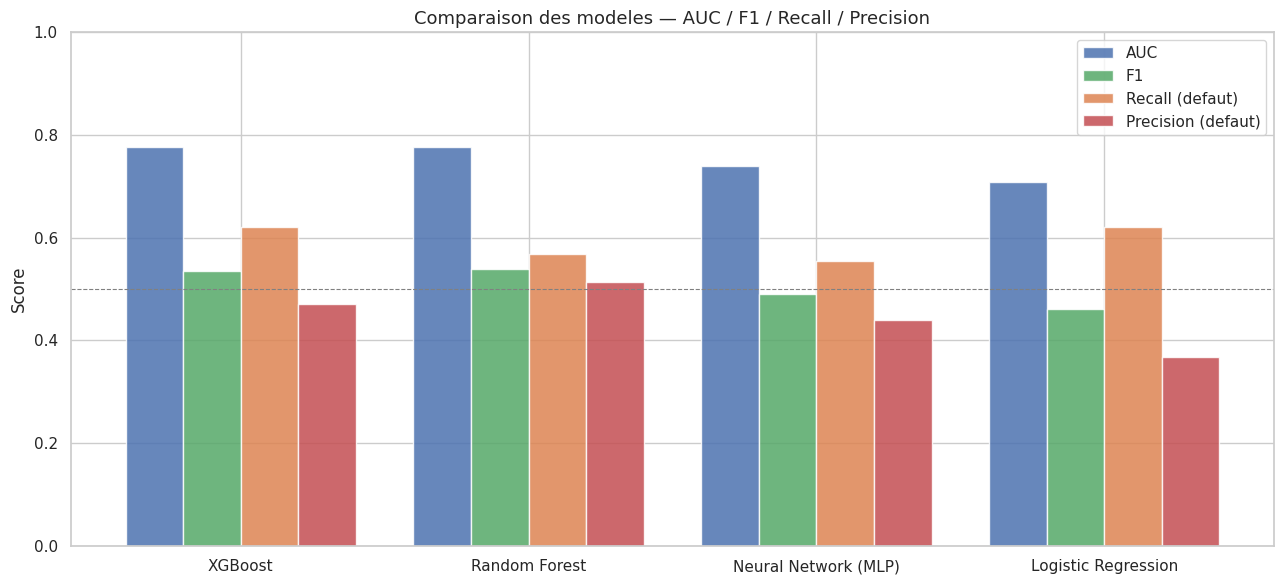

In [38]:
# --- Graphique de comparaison des metriques ---
metrics = ['AUC', 'F1', 'Recall (defaut)', 'Precision (defaut)']
x = np.arange(len(results_df))
width = 0.2
colors = ['#4C72B0', '#55A868', '#DD8452', '#C44E52']

fig, ax = plt.subplots(figsize=(13, 6))
for i, (metric, color) in enumerate(zip(metrics, colors)):
    ax.bar(x + i * width, results_df[metric], width, label=metric, color=color, alpha=0.85)

ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(results_df['Model'], rotation=0)
ax.set_ylim(0, 1)
ax.set_ylabel('Score')
ax.set_title('Comparaison des modeles — AUC / F1 / Recall / Precision')
ax.legend()
ax.axhline(y=0.5, color='grey', linestyle='--', linewidth=0.8, label='Baseline')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'model_comparison.png', dpi=100)
plt.show()

## 9. Discussion

### Ce qui a bien fonctionne
- Les variables de **retard de paiement** (`PAY_X`) sont de loin les plus predictives, confirmees par Lasso et Random Forest
- La gestion du desequilibre via **class_weight** et **SMOTE** ameliore significativement le recall sur les defauts
- **XGBoost et Random Forest** obtiennent les meilleurs AUC (> 0.78), confirmant l'interet des modeles non-lineaires
- Le **SMOTE sur le MLP** est correctement applique uniquement sur le train set, sans fuite vers le test

### Ce qui n'a pas fonctionne
- La **precision** reste limitee : beaucoup de faux positifs (clients sains classes comme risques)
- Le **MLP** est en retrait par rapport aux methodes ensemblistes malgre le SMOTE
- Les variables `BILL_AMT` brutes apportent peu de signal seules (multicollinearite)

### Interpretation metier
- Un client avec des **retards recents** (`PAY_0 > 0`) a 3x plus de risque de defaut
- Un **credit limit faible** est correlé avec le defaut (clients moins solvables)
- En finance, **minimiser les faux negatifs (FN)** est prioritaire : rater un defaut coute plus cher qu'un refus injustifie

## 10. Conclusion

- **Meilleur modele** : XGBoost / Random Forest (AUC ~0.78, F1 ~0.54)
- **Variables cles** : historique de paiement (`PAY_X`), limite de credit (`LIMIT_BAL`)
- **Desequilibre gere** : class_weight, scale_pos_weight, SMOTE selon le modele

### Ameliorations possibles
- Hyperparameter tuning (`GridSearchCV` / `RandomizedSearchCV`)
- Feature engineering (ratios utilisation, tendances de paiement)
- Optimisation du seuil de decision (threshold) selon le cout metier
- Analyse SHAP pour une interpretabilite plus fine